In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator

In [28]:
import kagglehub

output_dir = "./data5"

file_name = "student_productivity_distraction_dataset_20000.csv"

path = kagglehub.dataset_download(
    handle="sehaj1104/student-productivity-and-digital-distraction-dataset",
    output_dir=output_dir
)

In [29]:
RANDOM_STATE = 42

In [30]:
df = pd.read_csv(f"{output_dir}/{file_name}")
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


In [31]:
ORIGINAL_TARGET = "productivity_score"
TARGET = "class"
TARGET_LABELS = ["very_low", "low", "medium", "high", "very_high"]

TARGET_LABEL_IDX = {l:i for i, l in enumerate(TARGET_LABELS)}

df[TARGET] = pd.cut(
    df[ORIGINAL_TARGET],
    bins=[-1, 25, 45, 65, 80, 101],
    labels=TARGET_LABELS,
)

In [32]:
X = df.drop(labels=[TARGET, ORIGINAL_TARGET], axis=1)
y = df[TARGET]

In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [34]:
y.value_counts()

class
medium       8655
low          6405
high         3178
very_low     1196
very_high     566
Name: count, dtype: int64

In [35]:
from sklearn.preprocessing import LabelEncoder

GENDER = "gender"

X[GENDER] = LabelEncoder().fit_transform(X[GENDER])

y = np.array(list(map(lambda it: TARGET_LABEL_IDX[it], y)))

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [37]:
from sklearn.ensemble import RandomForestClassifier

def get_clf(**kwargs) -> RandomForestClassifier:
    # max_depth and n_estimators are from cross-validation
    return RandomForestClassifier(random_state=RANDOM_STATE, max_depth=8, n_estimators=200, **kwargs)

In [38]:
clf = get_clf()
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
from sklearn.metrics import confusion_matrix

def ovr(y_true, y_pred) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # cm[i, j] = {true=i, pred=j}
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = cm.sum()

    n_classes = len(TARGET_LABELS)

    tps = np.empty(n_classes)
    fps = np.empty_like(tps)
    tns = np.empty_like(tps)
    fns = np.empty_like(tps)
    supports = np.empty_like(tps, dtype=int)

    for i, label in enumerate(TARGET_LABELS):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        support = cm[i, :].sum()
        fn = support - tp
        tn = cm_sum - tp - fp - fn

        tps[i] = tp
        fps[i] = fp
        tns[i] = tn
        fns[i] = fn
        supports[i] = support

    return tps, fps, tns, fns, supports

In [40]:
def print_classification_report(y_true, y_pred) -> None:
    tps, fps, tns, fns, supports = ovr(y_true, y_pred)

    n_classes = len(TARGET_LABELS)

    precision_values = np.empty(n_classes)
    recall_values = np.empty(n_classes)
    specificity_values = np.empty(n_classes)
    f1_values = np.empty(n_classes)

    print(f"{' ':<15}{'precision':<11}{'recall':<8}{'f1-score':<10}{'specificity':<13}{'support':<9}\n")
    for i, label in enumerate(TARGET_LABELS):
        tp = tps[i]
        fp = fps[i]
        tn = tns[i]
        fn = fns[i]
        support = supports[i]

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        specificity = tn / (tn + fp)
        f1 = 2 * tp / (2 * tp + fp + fn)

        precision_values[i] = precision
        recall_values[i] = recall
        specificity_values[i] = specificity
        f1_values[i] = f1

        print(f"{label[:12]:<15}{round(precision, 2):<11}{round(recall, 2):<8}{round(f1, 2):<10}{round(specificity, 2):<13}{support:<9}")

    accuracy = tps.sum() / len(y_true)
    print(f"\n{'accuracy':<15}{' ':<29}{round(accuracy, 2)}")
    print(f"{'macro':<15}{round(precision_values.mean(), 2):<11}{round(recall_values.mean(), 2):<8}{round(f1_values.mean(), 2):<10}{round(specificity_values.mean(), 2):<13}")

In [41]:
print_classification_report(
    y_true=y_test,
    y_pred=clf.predict(X_test)
)

               precision  recall  f1-score  specificity  support  

very_low       1.0        0.22    0.36      1.0          234      
low            0.78       0.85    0.81      0.89         1265     
medium         0.76       0.93    0.84      0.78         1740     
high           0.77       0.52    0.62      0.97         646      
very_high      1.0        0.11    0.2       1.0          115      

accuracy                                    0.77
macro          0.86       0.53    0.57      0.93         


In [42]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from typing import Any

Estimator = Any

def cross_validation(estimator: Estimator, params: dict | None = None) -> tuple[np.ndarray, np.ndarray]:
    if params is None:
        params = {}

    X = X_train
    y = y_train

    n_splits = 5

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    cv_result = cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        return_estimator=True,
        return_indices=True,
        cv=cv,
        n_jobs=-1,
        params=params
    )

    test_indices = cv_result["indices"]["test"]
    estimators = cv_result["estimator"]

    n_classes = len(TARGET_LABELS)
    y_val_score = np.empty((y.shape[0], n_classes))
    y_val_pred = np.empty_like(y)

    # Out-of-fold
    for i, e in enumerate(estimators):
        test_idx = test_indices[i]
        X_val_i = X[test_idx]
        y_val_score[test_idx] = e.predict_proba(X_val_i)
        y_val_pred[test_idx] = e.predict(X_val_i)

    return y_val_score, y_val_pred

In [43]:
from sklearn.metrics import RocCurveDisplay

def draw_roc_curve(
        y_true: np.ndarray,
        y_score: np.ndarray,
        ax: plt.Axes,
        label: str,
        color: str,
        chance_level: bool = False
) -> None:
    auc = roc_auc_score(y_true, y_score)

    _ = RocCurveDisplay.from_predictions(
        y_true=y_true,
        y_score=y_score,
        ax=ax,
        plot_chance_level=chance_level,
        curve_kwargs={
            "color": color,
            "label": f"{label} (AUC = {round(auc, 2)})",
            "linewidth": 2.5,
        },
        chance_level_kw={"color": "white", "linewidth": 2.5})

In [44]:
from sklearn.metrics import PrecisionRecallDisplay

def draw_pr_curve(y_true: np.ndarray, y_score: np.ndarray, ax: plt.Axes, label: str, color: str, chance_level: bool = False) -> None:
    _ = PrecisionRecallDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_score,
        ax=ax,
        color=color,
        label=label,
        linewidth=2.5,
        plot_chance_level=chance_level,
        chance_level_kw={
            "color": "white",
            "linewidth": 2.5,
        },
    )

In [45]:
y_train_score = clf.predict_proba(X_train)
y_val_score, _ = cross_validation(clf)
y_test_score = clf.predict_proba(X_test)

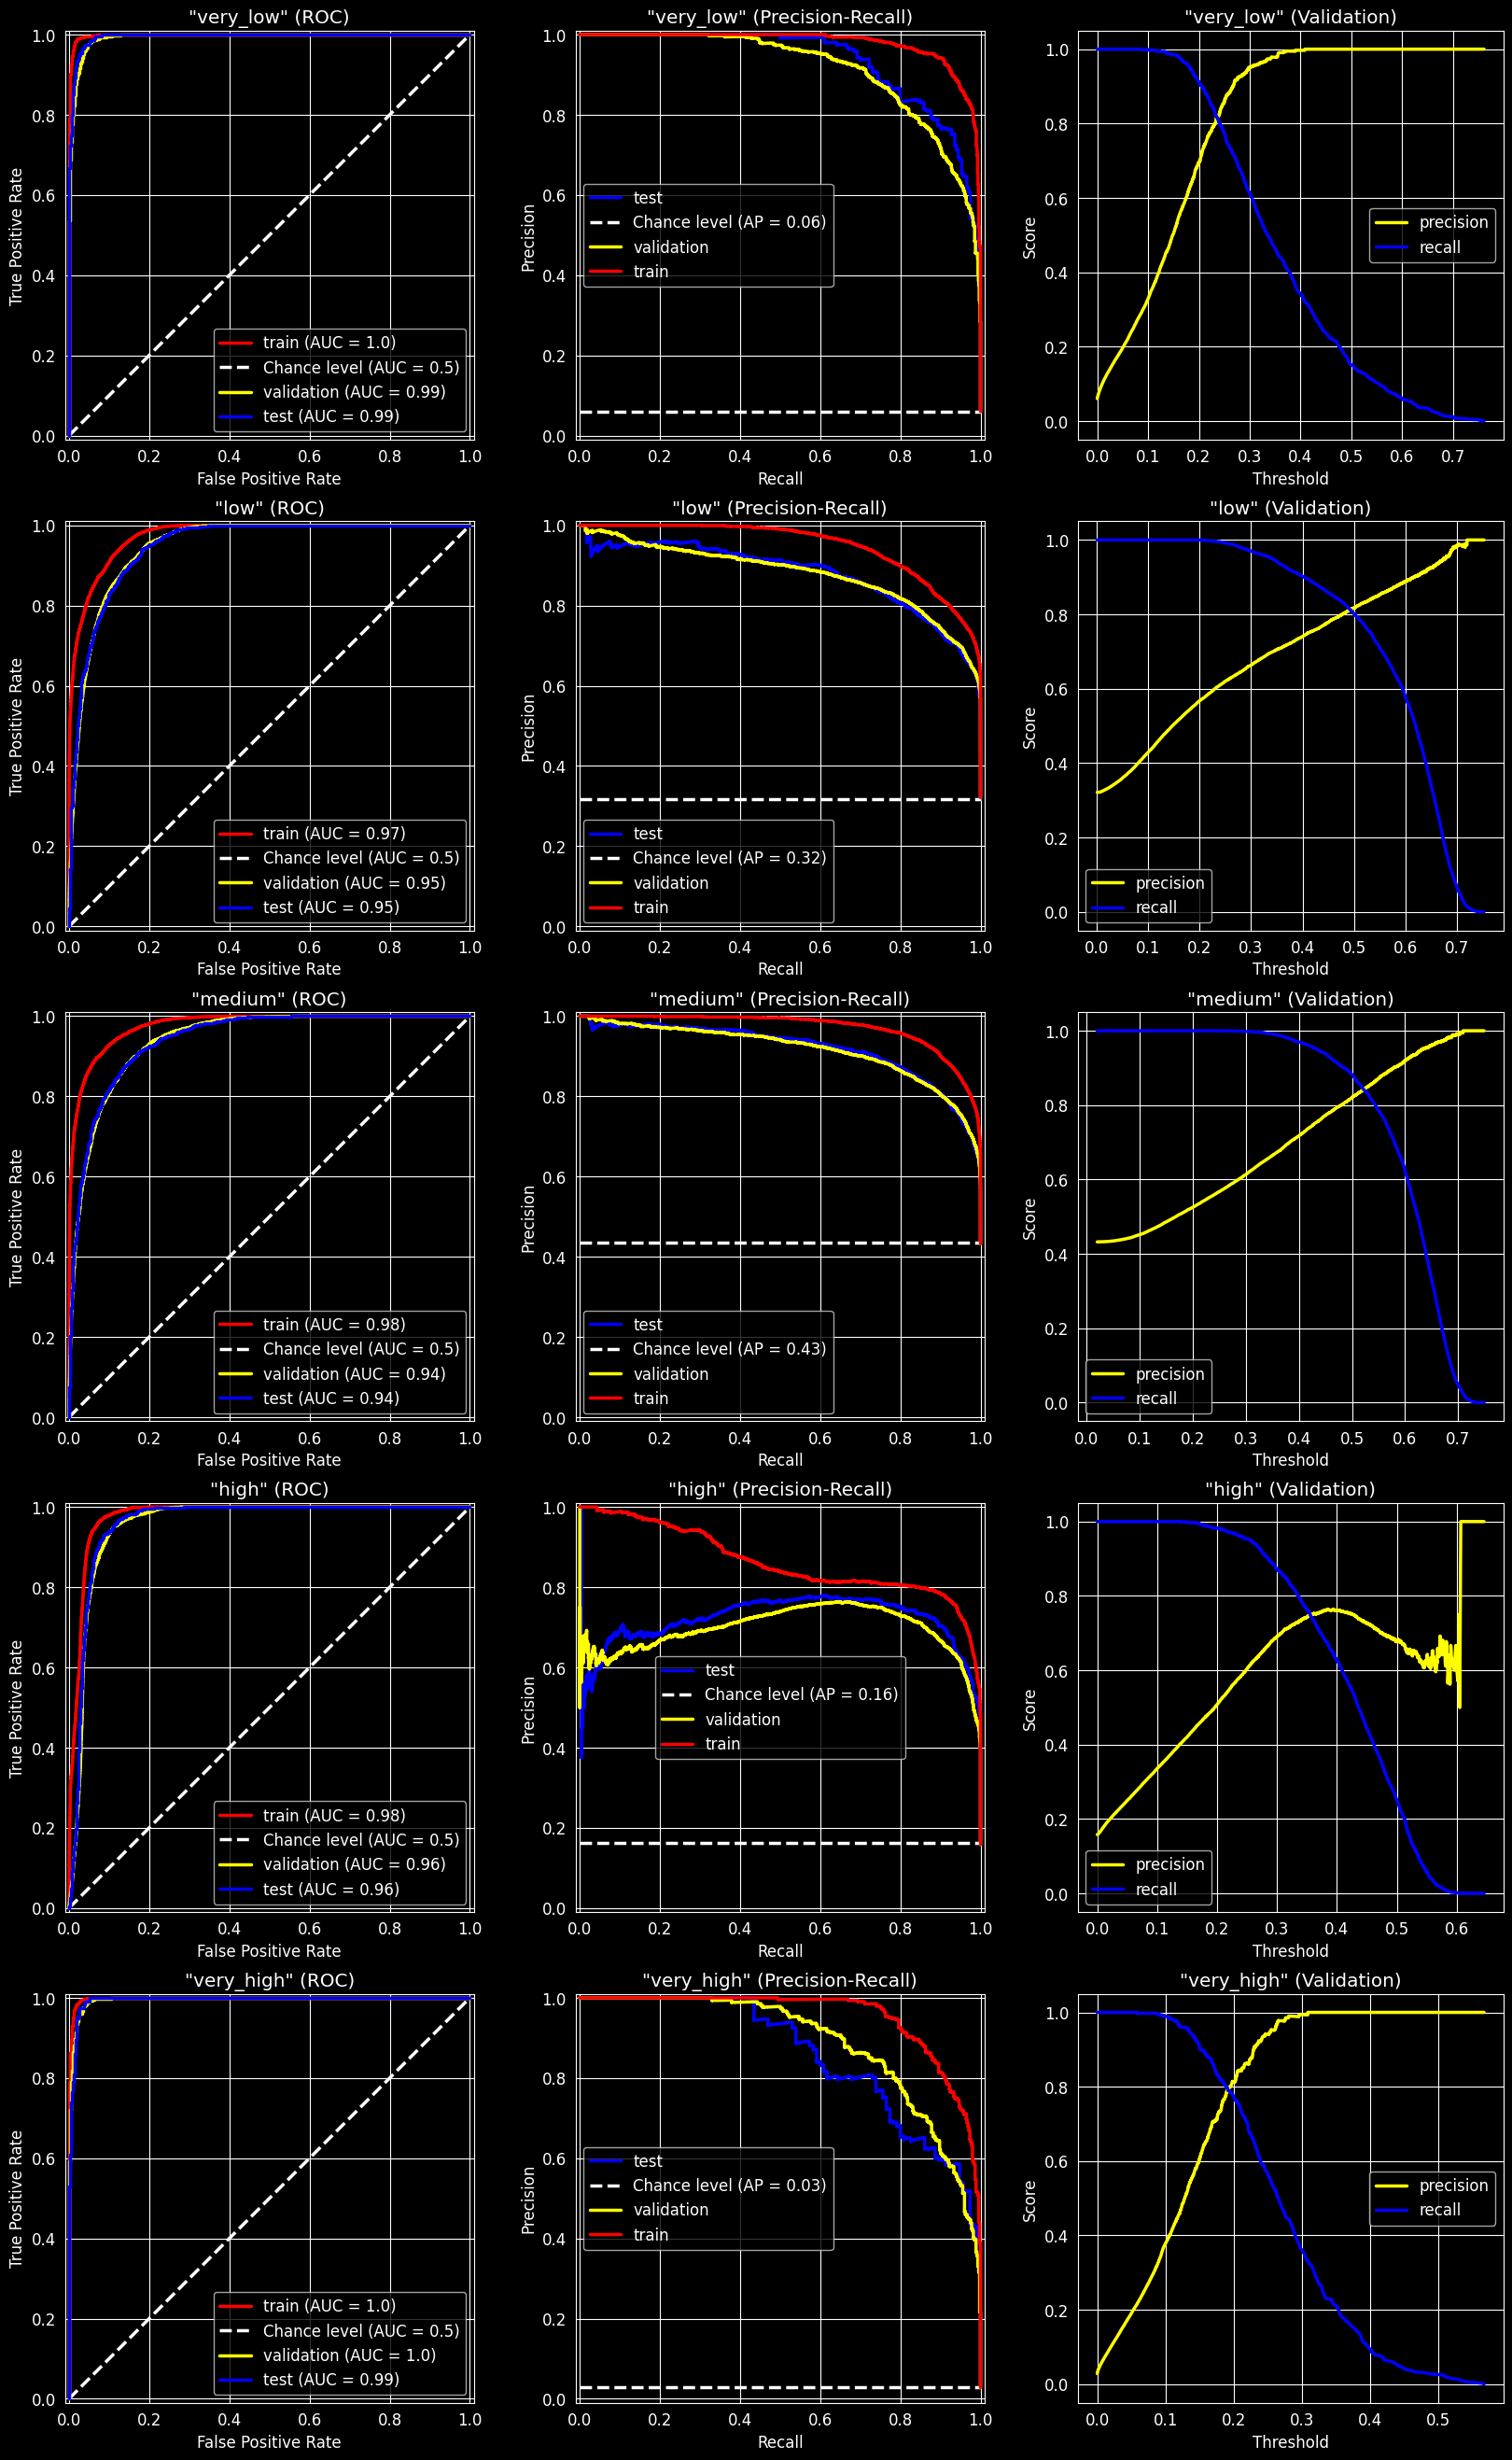

In [46]:
from sklearn.metrics import precision_recall_curve, roc_auc_score

fig, axs = plt.subplots(5, 3, figsize=(20, 33))
plt.rcParams['font.size'] = 12

for i, class_label in enumerate(TARGET_LABELS):
    # Binary classification for class i
    y_train_true_i = (y_train == i).astype(int)
    y_train_score_i = y_train_score[:, i]

    # Cross-validation was performed on train set, so y_val_score is the probabilities for the y_train
    y_val_true_i = y_train_true_i
    y_val_score_i = y_val_score[:, i]

    y_test_true_i = (y_test == i).astype(int)
    y_test_score_i = y_test_score[:, i]

    roc_ax = axs[i, 0]
    draw_roc_curve(
        y_true=y_train_true_i,
        y_score=y_train_score_i,
        ax=roc_ax,
        label="train",
        color="red",
        chance_level=True  # chance_level is equal True only here in ROC, to prevent 3 identical chance-level-lines (for train, validation and test)
    )
    draw_roc_curve(
        y_true=y_val_true_i,
        y_score=y_val_score_i,
        ax=roc_ax,
        label="validation",
        color="yellow"
    )
    draw_roc_curve(
        y_true=y_test_true_i,
        y_score=y_test_score_i,
        ax=roc_ax,
        label="test",
        color="blue"
    )
    roc_ax.set_title(f"\"{class_label}\" (ROC)")
    roc_ax.legend(loc="best")
    roc_ax.set_xlabel("False Positive Rate")
    roc_ax.set_ylabel("True Positive Rate")

    pr_ax = axs[i, 1]
    draw_pr_curve(
        y_true=y_test_true_i,
        y_score=y_test_score_i,
        ax=pr_ax,
        label=f"test",
        color="blue",
        chance_level=True  # chance_level is equal True only here in PR, to prevent 3 identical chance-level-lines (for train, validation and test)
    )
    draw_pr_curve(
        y_true=y_val_true_i,
        y_score=y_val_score_i,
        ax=pr_ax,
        label=f"validation",
        color="yellow"
    )
    draw_pr_curve(
        y_true=y_train_true_i,
        y_score=y_train_score_i,
        ax=pr_ax,
        label=f"train",
        color="red"
    )
    pr_ax.set_title(f"\"{class_label}\" (Precision-Recall)")
    pr_ax.legend(loc="best")
    pr_ax.set_xlabel("Recall")
    pr_ax.set_ylabel("Precision")

    threshold_ax = axs[i, 2]
    precision_val_i, recall_val_i, thresholds_val_i = precision_recall_curve(
        y_true=y_val_true_i,
        y_score=y_val_score_i,
    )
    threshold_ax.plot(thresholds_val_i, precision_val_i[1:], color="yellow", label="precision", linewidth=2.5)
    threshold_ax.plot(thresholds_val_i, recall_val_i[1:], color="blue", label="recall", linewidth=2.5)
    threshold_ax.set_title(f"\"{class_label}\" (Validation)")
    threshold_ax.legend(loc="best")
    threshold_ax.set_xlabel("Threshold")
    threshold_ax.set_ylabel("Score")

In [47]:
class CustomThresholdClassifier:
    def __init__(self, model: Any, thresholds: list[float], order: list[int]):
        self.__model = model
        self.__thresholds = thresholds
        self.__order = order

    def get_params(self, deep=True) -> dict:
        # This method is implement to allow this classifier be used in cross-validation

        return {
            "model": self.__model,
            "thresholds": self.__thresholds,
            "order": self.__order
        }

    def fit(self, X, y):
        self.__model.fit(X, y)

    def predict(self, X) -> np.ndarray:
        return np.array(list(map(self.__predict, clf.predict_proba(X))))

    def score(self, X, y):
        # This method is implement to allow this classifier be used in cross-validation with default scoring

        return -1

    def __predict(self, y_score: np.ndarray) -> int:
        for c in self.__order:
            if y_score[c] >= self.__thresholds[c]:
                return c

        return int(y_score.argmax())

    def predict_proba(self, X) -> np.ndarray:
        return self.__model.predict_proba(X)

In [48]:
from sklearn.utils import compute_sample_weight

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

In [49]:
models = [
    (
        "gini",
        clf,
    ),
    (
        "entropy",
        get_clf(criterion="entropy")
    ),
    (
        "threshold",
        CustomThresholdClassifier(
            model=clf,
            thresholds=[0.24, 0.5, 0.52, 0.36, 0.2],
            order=[4, 0, 3, 1, 2]
        )
    ),
    (
        "balanced",
        get_clf(class_weight="balanced")
    ),
    (
        "balanced subsample",
        get_clf(class_weight="balanced_subsample")
    ),
    (
        "sample weight",
        get_clf(),
        {"sample_weight": sample_weight}
    ),
    (
        "sample weight + balanced",
        get_clf(class_weight="balanced_subsample"),
        {"sample_weight": sample_weight}
    )
]

In [50]:
from sklearn.metrics import roc_auc_score, f1_score
from termcolor import colored

print(f"{'':<37}{'AUC':<30}{'F1':<24}")
print(f"{'':<28}{'min':<9}{'avg':<9}{'max':<12}{'min':<9}{'avg':<9}{'max':<12}\n")
for item in models:
    label = item[0]
    clf = item[1]

    if len(item) > 2:
        data = item[2]
    else:
        data = {}

    y_true = y_train
    y_score, y_pred = cross_validation(clf, data)

    # with multi_class="ovr", average=None function returns an array of auc-scores for each class
    auc = roc_auc_score(y_true, y_score, multi_class="ovr", average=None)
    auc_min = round(auc.min(), 2)
    auc_avg = round(auc.mean(), 2)
    auc_max = round(auc.max(), 2)

    f1 = f1_score(y_true, y_pred, average=None)
    f1_min = round(f1.min(), 2)
    f1_avg = round(f1.mean(), 2)
    f1_max = round(f1.max(), 2)

    if f1_avg < 0.8:
        color = "red"
    else:
        color = "green"

    print(f"{label:<28}{auc_min:<9}{auc_avg:<9}{auc_max:<12}{f1_min:<9}{colored(f1_avg, color):<18}{f1_max:<12}")

                                     AUC                           F1                      
                            min      avg      max         min      avg      max         

gini                        0.94     0.97     1.0         0.11     0.54     0.84        
entropy                     0.94     0.97     0.99        0.17     0.58     0.84        
threshold                   0.94     0.97     1.0         0.86     0.89     0.92        
balanced                    0.95     0.97     0.99        0.76     0.8      0.84        
balanced subsample          0.95     0.97     0.99        0.77     0.8      0.83        
sample weight               0.95     0.97     0.99        0.76     0.8      0.84        
sample weight + balanced    0.9      0.94     0.99        0.51     0.56     0.66        
